In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv(
    "KDDTrain+.txt",
    sep=",",
)
pd.set_option("display.max_columns",None)

In [2]:
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.18,2,2.1,0.00,0.00.1,0.00.2,0.00.3,1.00,0.00.4,0.00.5,150,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [3]:
df.describe()

,0,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.18,2,2.1,0.00,0.00.1,0.00.2,0.00.3,1.00,0.00.4,0.00.5,150,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,20
count,125972.000000,1.259720e+05,1.259720e+05,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.0,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000,125972.000000
mean,287.146929,4.556710e+04,1.977927e+04,0.000198,0.022688,0.000111,0.204411,0.001222,0.395739,0.279253,0.001342,0.001103,0.302194,0.012669,0.000413,0.004096,0.0,0.000008,0.009423,84.108207,27.738093,0.284487,0.282488,0.119959,0.121184,0.660925,0.063053,0.097322,182.149200,115.653725,0.521244,0.082952,0.148379,0.032543,0.284455,0.278487,0.118832,0.120241,19.504056
std,2604.525522,5.870354e+06,4.021285e+06,0.014086,0.253531,0.014366,2.149977,0.045239,0.489011,23.942137,0.036603,0.045155,24.399715,0.483937,0.022181,0.099370,0.0,0.002817,0.096613,114.508828,72.636092,0.446457,0.447024,0.320437,0.323648,0.439624,0.180315,0.259831,99.206565,110.702886,0.448950,0.188922,0.308998,0.112564,0.444785,0.445670,0.306559,0.319460,2.291512
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.0,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   0         125972 non-null  int64  
 1   tcp       125972 non-null  object 
 2   ftp_data  125972 non-null  object 
 3   SF        125972 non-null  object 
 4   491       125972 non-null  int64  
 5   0.1       125972 non-null  int64  
 6   0.2       125972 non-null  int64  
 7   0.3       125972 non-null  int64  
 8   0.4       125972 non-null  int64  
 9   0.5       125972 non-null  int64  
 10  0.6       125972 non-null  int64  
 11  0.7       125972 non-null  int64  
 12  0.8       125972 non-null  int64  
 13  0.9       125972 non-null  int64  
 14  0.10      125972 non-null  int64  
 15  0.11      125972 non-null  int64  
 16  0.12      125972 non-null  int64  
 17  0.13      125972 non-null  int64  
 18  0.14      125972 non-null  int64  
 19  0.15      125972 non-null  int64  
 20  0.16

Adding column names

In [5]:
df.columns =  [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "class",
    "difficulty"
]

In [6]:
attack_mapping = {

    # normal
    "normal": "normal",

    # DoS
    "neptune": "dos",
    "smurf": "dos",
    "back": "dos",
    "teardrop": "dos",
    "pod": "dos",
    "land": "dos",

    # Probe
    "satan": "probe",
    "ipsweep": "probe",
    "portsweep": "probe",
    "nmap": "probe",

    # R2L
    "guess_passwd": "r2l",
    "warezclient": "r2l",
    "warezmaster": "r2l",
    "ftp_write": "r2l",
    "imap": "r2l",
    "multihop": "r2l",
    "phf": "r2l",
    "spy": "r2l",

    # U2R
    "buffer_overflow": "u2r",
    "loadmodule": "u2r",
    "rootkit": "u2r",
    "perl": "u2r",
}

df["class"] = df["class"].map(attack_mapping)

In [7]:
df['class'].value_counts()

class
normal    67342
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

# Splitting X and Y for Simplification 


In [8]:
oh = OneHotEncoder(sparse_output=False)

X = df.drop(['class'],axis = 1)
y = pd.DataFrame(oh.fit_transform(df[['class']]),columns= oh.get_feature_names_out(['class']))

#Encoding

In [9]:
df_tcp_trans = pd.DataFrame(oh.fit_transform(X[['protocol_type']]),columns= oh.get_feature_names_out(["protocol_type"]))

In [10]:
df_REJ_trans = pd.DataFrame(oh.fit_transform(X[['flag']]),columns= oh.get_feature_names_out(["flag"]))

In [11]:
df_private_trans = pd.DataFrame(oh.fit_transform(X[['service']]),columns= oh.get_feature_names_out(["service"]))

In [12]:
X = pd.concat([X,df_tcp_trans,df_private_trans,df_REJ_trans],axis= 1)

In [13]:
X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_harvest,service_hostnames,service_http,service_http_2784,service_http_443,service_http_8001,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,15,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,19,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,21,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,21,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,21,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [14]:
y.head()

,class_dos,class_normal,class_probe,class_r2l,class_u2r
0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0


In [15]:
X.drop(['protocol_type','service','flag'],axis = 1,inplace = True)

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Columns: 123 entries, duration to flag_SH
dtypes: float64(99), int64(24)
memory usage: 118.2 MB


In [17]:
print(list(y.columns))

['class_dos', 'class_normal', 'class_probe', 'class_r2l', 'class_u2r']


#Model Training / Validation

Splitting into train, test and validaiton sets

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   
X_test  = scaler.transform(X_test)


In [19]:
y_test.shape
#y_train.shape


(25195, 5)

In [20]:
# from sklearn.tree import DecisionTreeClassifier

# dtc = DecisionTreeClassifier(criterion='gini',max_depth = 4,class_weight="balanced")

# dtc.fit(X_train,y_train)

# dtc_pred = dtc.predict(X_test)
# print(accuracy_score(y_test,dtc_pred))
# print(classification_report(y_test,dtc_pred,zero_division=0))

# Random Forest

In [21]:
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=7,
    random_state=42,
    class_weight='balanced'
)

rf_clf.fit(X_train, y_train)
y_val_pred_rf = rf_clf.predict(X_test)


In [22]:
print("Random Forest (val):")
print(classification_report(y_test, y_val_pred_rf, zero_division=0))
print("Accuracy = ", accuracy_score(y_test,y_val_pred_rf))

Random Forest (val):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      9186
           1       1.00      0.92      0.96     13469
           2       0.99      0.98      0.99      2331
           3       0.86      0.98      0.92       199
           4       0.83      1.00      0.91        10

   micro avg       1.00      0.94      0.97     25195
   macro avg       0.94      0.97      0.95     25195
weighted avg       1.00      0.94      0.97     25195
 samples avg       0.94      0.94      0.94     25195

Accuracy =  0.9438380631077595


In [23]:
y_test_rfc = np.argmax(y_test, axis=1)
y_val_pred_rf = np.argmax(y_val_pred_rf, axis=1)
pd.DataFrame(confusion_matrix(y_test_rfc, y_val_pred_rf))

,0,1,2,3,4
0,9174,0,12,0,0
1,960,12455,21,31,2
2,35,0,2296,0,0
3,4,0,0,195,0
4,0,0,0,0,10


# Logistic Regression

In [24]:
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# le = LabelEncoder()
# y_lr = le.fit_transform(df['class'])

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_lr,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )
# pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", LogisticRegression(
#         max_iter=500,
#         class_weight="balanced",
#         solver="lbfgs",
#         multi_class="auto"
#     ))
# ])

# pipeline.fit(X_train, y_train_lr)


In [25]:
# y_pred = pipeline.predict(X_test)
# y_prob = pipeline.predict_proba(X_test)

# print("Classification Report:\n")
# print(classification_report(y_test, y_pred,zero_division =0))
# print(accuracy_score(y_test,y_pred))

# XGBoost 

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators = 200,
                    n_jobs=-1,
                    learning_rate = 0.01,
                    max_depth = 2
                   )

In [27]:
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
print("Accuracy:",accuracy_score(xgb_pred,y_test))
print(classification_report(xgb_pred,y_test,zero_division=0))

Accuracy: 0.9568565191506251
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8825
           1       0.98      0.98      0.98     13565
           2       0.91      0.99      0.95      2152
           3       0.77      0.99      0.87       156
           4       0.30      1.00      0.46         3

   micro avg       0.97      0.99      0.98     24701
   macro avg       0.79      0.99      0.85     24701
weighted avg       0.97      0.99      0.98     24701
 samples avg       0.97      0.96      0.96     24701



# Applying Voting Classifier

In [28]:
y_train_vc = np.argmax(y_train, axis=1)
y_test_vc = np.argmax(y_test, axis=1)

In [29]:
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(
    estimators = [
        ('rfc',RandomForestClassifier(
        n_estimators=50,
        max_depth=7,
        random_state=42,
        class_weight='balanced'
        )),
        
        ('xgb',XGBClassifier(n_estimators = 200,
                    n_jobs=-1,
                    learning_rate = 0.01,
                    max_depth = 2
                   ))],
        n_jobs = -1,
        voting ='soft'
        
)

In [30]:
y_train.shape

(100777, 5)

In [31]:
vc.fit(X_train,y_train_vc)
vc_pred = vc.predict(X_test)

print(accuracy_score(y_test_vc,vc_pred))
print(classification_report(y_test_vc,vc_pred,zero_division=0))

0.9876562810081365
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      9186
           1       0.99      0.99      0.99     13469
           2       0.97      0.97      0.97      2331
           3       0.89      0.97      0.93       199
           4       0.77      1.00      0.87        10

    accuracy                           0.99     25195
   macro avg       0.92      0.98      0.95     25195
weighted avg       0.99      0.99      0.99     25195



In [32]:
pd.DataFrame(confusion_matrix(y_test_vc, vc_pred))

,0,1,2,3,4
0,9045,123,18,0,0
1,18,13372,53,24,2
2,2,65,2263,1,0
3,0,4,0,194,1
4,0,0,0,0,10


# Applying ANN

In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers ,regularizers

num_classes = len(set(y))

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),

    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),

    layers.Dense(num_classes, activation='softmax')
])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          31,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,061 (301.02 KB)

 Trainable params: 76,101 (297.27 KB)

 Non-trainable params: 960 (3.75 KB)

In [37]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [39]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    batch_size=512
)


Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9823 - loss: 0.3333 - val_accuracy: 0.9453 - val_loss: 0.2357
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9893 - loss: 0.1184 - val_accuracy: 0.9847 - val_loss: 0.1228
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.1067 - val_accuracy: 0.9731 - val_loss: 0.1436
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9890 - loss: 0.1024 - val_accuracy: 0.9872 - val_loss: 0.1403
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9898 - loss: 0.1031 - val_accuracy: 0.9846 - val_loss: 0.1102
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9897 - loss: 0.1014 - val_accuracy: 0.9890 - val_loss: 0.0853
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9896 - loss: 0.0989 - val_accuracy: 0.9812 - val_loss: 0.1191
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9913 - loss: 0.0796 - val_accu

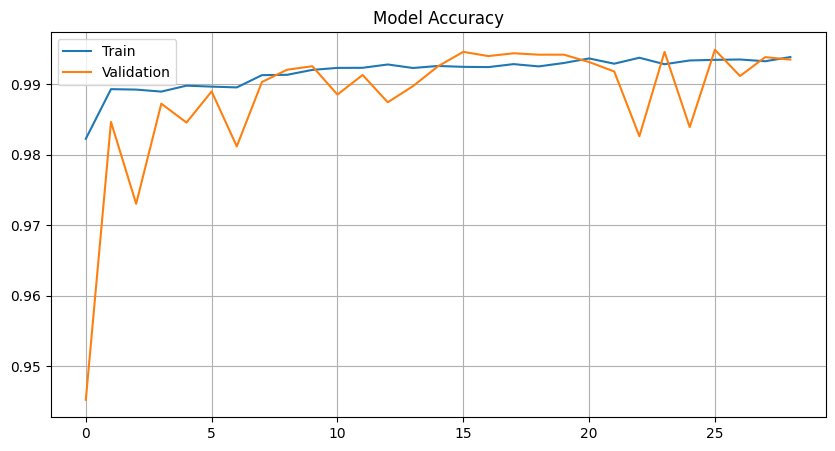

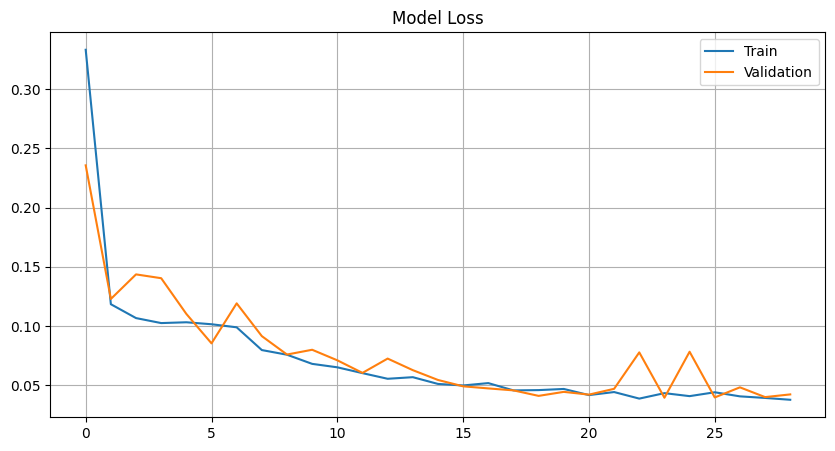

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()


In [45]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score,f1_score,confusion_matrix

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print(classification_report(y_test_labels, y_pred,zero_division = False))
print("Accuracy:", accuracy_score(y_test_labels, y_pred))


788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step - accuracy: 0.9946 - loss: 0.0419
Test Accuracy: 0.9946417808532715
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9186
           1       1.00      0.99      1.00     13469
           2       0.99      0.99      0.99      2331
           3       0.85      0.97      0.91       199
           4       0.00      0.00      0.00        10

    accuracy                           0.99     25195
   macro avg       0.77      0.79      0.78     25195
weighted avg       0.99      0.99      0.99     25195

Accuracy: 0.9946417940067473


In [44]:
pd.DataFrame(confusion_matrix(y_test_labels, y_pred))

,0,1,2,3,4
0,9172,12,2,0,0
1,25,13393,26,25,0
2,12,14,2301,4,0
3,0,5,0,194,0
4,0,4,0,6,0
